# SAR 画像のカラー化の実装

## サンプルデータ
[Sentinel-1 衛星画像](../data/)

In [ ]:
import os

import tifffile
import matplotlib.pyplot as plt
import numpy as np

## 基本設定

In [3]:
PATH_OUTPUT = 'output/002/'
os.makedirs(PATH_OUTPUT, exist_ok=True)

PATH_VV = "../data/Sentinel-1_VV.tiff"
PATH_VH = "../data/Sentinel-1_VH.tiff"

## 画像読み込み

In [4]:
img_vv = tifffile.imread(PATH_VV).astype(np.float32)[..., 0]
img_vh = tifffile.imread(PATH_VH).astype(np.float32)[..., 0]

img_vv /= 63536.0  # 16bit最大値
img_vh /= 63536.0

# RGB Raito Color

### HighlightCompressVisualizer

In [ ]:
def db_to_linear(db):
    """dB → 線形（γ⁰）"""
    return np.power(10.0, db / 10.0)

def highlight_compress(x, minv=0.0, maxv=0.8):
    """
    Sentinel HubのHighlightCompressVisualizer相当の簡易実装（per-channel）。
    ・minv → 0,  maxv → 約0.9259 に写像
    ・その先は緩やかに 1.0 に近づける（2*maxv - minv で 1.0）
    """
    a, b = float(minv), float(maxv)
    x = np.asarray(x, dtype=np.float32)

    # しきい値
    th1 = a + 0.92 * (b - a)
    th2 = 2.0 * b - a

    y = np.zeros_like(x, dtype=np.float32)

    # 区間1: a < x <= th1  → 0..0.92 の線形
    mask1 = (x > a) & (x <= th1)
    y[mask1] = (x[mask1] - a) / (b - a)

    # 区間2: th1 < x < th2 → 0.92..1.0 の緩勾配線形
    mask2 = (x > th1) & (x < th2)
    # 傾き 0.08 / (th2 - th1) = 0.08 / (1.08*(b-a)) ≒ 0.074074/(b-a)
    slope2 = 0.08 / (th2 - th1)
    y[mask2] = 0.92 + slope2 * (x[mask2] - th1)

    # 区間3: x >= th2 → 1.0
    y[x >= th2] = 1.0

    return np.clip(y, 0.0, 1.0)

def rgb_ratio_from_vv_vh(vv, vh, gain=0.4, unit='linear'):
    """
    Copernicus Browser / Sentinel Hubの RGB-RATIO を再現。
    Parameters
    ----------
    vv, vh : 2D np.ndarray
        VV, VH の画素値。unit='linear' のとき γ⁰（線形）、unit='dB' なら dB 値。
    unit : {'linear', 'dB'}
    Returns
    -------
    rgb : (H, W, 3) float32
        各チャンネル0..1に正規化済み。
    """
    if unit == 'dB':
        vv_lin = db_to_linear(vv)
        vh_lin = db_to_linear(vh)
    else:
        vv_lin = vv.astype(np.float32)
        vh_lin = vh.astype(np.float32)

    # 安全策（ゼロ割防止）
    vv_lin = np.maximum(vv_lin, 1e-10)
    vh_lin = np.maximum(vh_lin, 0.0)

    # 公式スクリプトの正規化係数と同じ値
    r_raw = (gain * vv_lin) / 0.28
    g_raw = (gain * vh_lin) / 0.06
    b_raw = (gain * (vh_lin / vv_lin)) / 0.49

    # チャンネル毎にハイライト圧縮
    r = highlight_compress(r_raw, 0.0, 0.8)
    g = highlight_compress(g_raw, 0.0, 0.8)
    b = highlight_compress(b_raw, 0.0, 0.8)

    rgb = np.stack([r, g, b], axis=-1).astype(np.float32)
    return np.clip(rgb, 0.0, 1.0)



In [5]:
rgb_ratio = rgb_ratio_from_vv_vh(img_vv, img_vh, 
                                #  unit='dB', 
                                unit='linear', 
                                 gain=0.8
                                 )
rgb_ratio_u8 = (rgb_ratio * 255).round().astype(np.uint8)

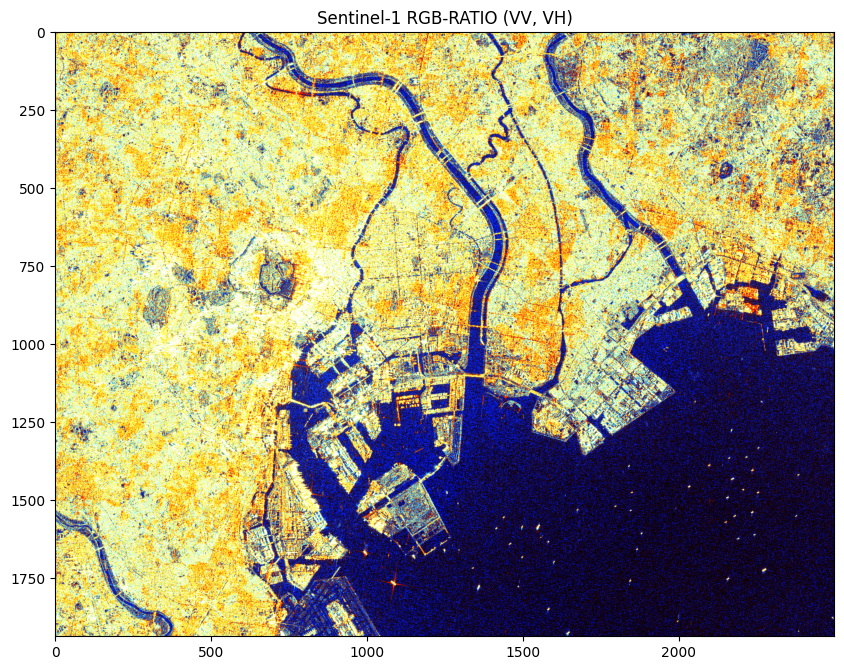

In [6]:
# 可視化
plt.figure(figsize=(16, 8), dpi=100, facecolor='white', edgecolor='black')
plt.imshow(rgb_ratio_u8)
plt.title('Sentinel-1 RGB-RATIO (VV, VH)')
plt.savefig(os.path.join(PATH_OUTPUT, 'sentinel1_rgb_ratio.png'), bbox_inches='tight', pad_inches=0.1)
plt.show() 

In [7]:
plt.imsave(os.path.join(PATH_OUTPUT, 'sentinel1_rgb_ratio_vv_vh.png'), rgb_ratio_u8)

# False Color
* 作者: Annamaria Luongo


In [8]:
def s1_sar_false_color_from_gamma0(
    vv, vh, *, unit="linear", enhanced=False, clip=True, eps=1e-12
):
    """
    Sentinel Hub『SAR False Color Visualization』の再現。
    入力:
        vv, vh : 2D配列（VV, VH）; unit='linear' なら γ⁰(線形), 'dB' なら γ⁰(dB)
        enhanced : True で Enhanced 版、False で Non-enhanced 版
        clip : 出力を [0,1] にクリップするか
        eps : logの定義域確保用の微小値
    戻り値:
        rgb : (H, W, 3) の float32（0..1想定）
    参照:
        https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-1/sar_false_color_visualization/
    """
    # 1) γ⁰を線形に統一
    vv = np.asarray(vv, dtype=np.float32)
    vh = np.asarray(vh, dtype=np.float32)
    if unit.lower() == "db":
        vv = db_to_linear(vv)
        vh = db_to_linear(vh)

    # 2) 定数（Evalscriptの値のまま）
    c1, c2, c3 = 1e-3, 0.01, 0.02
    c4, c5, c6 = 0.03, 0.045, 0.05
    c7, c8 = 0.9, 0.25

    # 3) Non-enhanced / Enhanced の分岐（log の定義域は eps で保護）
    if not enhanced:
        termR = c1 - np.log(c6 / (c3 + 2.0 * vv + eps) + eps)
        R = c4 + np.log(np.maximum(termR, eps))

        G = c6 + np.exp(
            c8 * (np.log(c2 + 2.0 * vv + eps) + np.log(c3 + 5.0 * vh + eps))
        )

        B = 1.0 - np.log(c6 / (c5 - c7 * vv + eps) + eps)
    else:
        termR = (
            c1
            - np.log(c6 / (c3 + 2.5 * vv + eps) + eps)
            + np.log(c6 / (c3 + 1.5 * vh + eps) + eps)
        )
        R = c4 + np.log(np.maximum(termR, eps))

        G = c6 + np.exp(
            c8 * (np.log(c2 + 2.0 * vv + eps) + np.log(c3 + 7.0 * vh + eps))
        )

        B = 0.8 - np.log(c6 / (c5 - c7 * vv + eps) + eps)

    rgb = np.stack([R, G, B], axis=-1).astype(np.float32)
    if clip:
        rgb = np.clip(rgb, 0.0, 1.0)
    return rgb


/var/folders/vg/3f79b2x54mz7ny6lbm1bfhrw0000gn/T/ipykernel_28511/1760182916.py:50: RuntimeWarning: invalid value encountered in log
  B = 0.8 - np.log(c6 / (c5 - c7 * vv + eps) + eps)


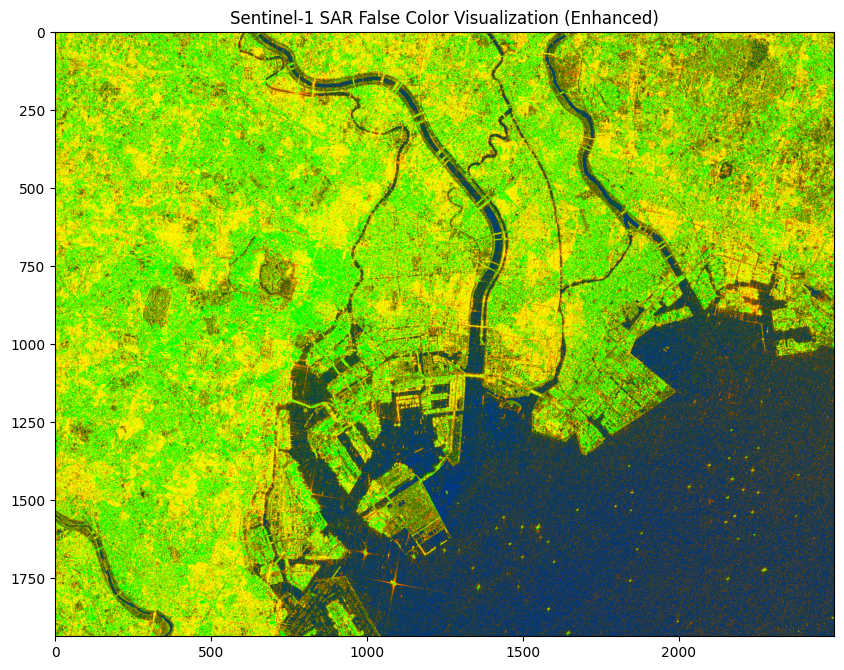

In [9]:
false_color = s1_sar_false_color_from_gamma0(img_vv, img_vh, unit='linear', enhanced=True)
false_color_u8 = (false_color * 255).round().astype(np.uint8)

# 可視化
plt.figure(figsize=(16, 8), dpi=100, facecolor='white', edgecolor='black')
plt.imshow(false_color_u8)
plt.title('Sentinel-1 SAR False Color Visualization (Enhanced)')
plt.savefig(os.path.join(PATH_OUTPUT, 'sentinel1_sar_false_color.png'), bbox_inches='tight', pad_inches=0.1)
plt.show();
plt.imsave(os.path.join(PATH_OUTPUT, 'sentinel1_sar_false_color_vv_vh.png'), false_color_u8)

# Urban Area Color
* 作者: Monja B. Šebela 



In [10]:
def s1_urban_areas_from_gamma0(
    vv, vh,
    *, unit="linear",
    r_scale=5.5, r_thresh=0.5,  # R: 5.5*VH > 0.5
    b_scale=8.0,                # B: VH*8
    clip=True, eps=1e-12, return_mask=False
):
    """
    Sentinel Hub『Urban Areas Script』のPython実装（γ⁰想定）。
    入力:
        vv, vh : 2D配列（VV, VH）
        unit   : 'linear' (γ⁰), 'dB' (γ⁰[dB])
    パラメータ:
        r_scale, r_thresh : 赤チャンネルの倍率・閾値（既定: 5.5, 0.5）
        b_scale           : 青チャンネルの倍率（既定: 8.0）
        clip              : 出力RGBを[0,1]へクリップ
        return_mask       : Trueで( rgb, mask )を返す（maskは有効画素の簡易判定）
    戻り値:
        rgb (H,W,3) float32 in [0,1]（optionで mask も）
    参照: https://custom-scripts.sentinel-hub.com/sentinel-1/urban_areas/
    """
    vv = np.asarray(vv, dtype=np.float32)
    vh = np.asarray(vh, dtype=np.float32)
    if unit.lower() == "db":
        vv = db_to_linear(vv)
        vh = db_to_linear(vh)

    # 値域保護
    vv = np.maximum(vv, 0.0)
    vh = np.maximum(vh, 0.0)

    # Urban Areas Script の再現
    R = (r_scale * vh > r_thresh).astype(np.float32)  # 二値
    G = vv
    B = b_scale * vh

    rgb = np.stack([R, G, B], axis=-1)
    if clip:
        rgb = np.clip(rgb, 0.0, 1.0).astype(np.float32)

    if return_mask:
        mask = np.isfinite(vv) & np.isfinite(vh) & (vv >= 0) & (vh >= 0)
        return rgb, mask.astype(np.uint8)
    return rgb.astype(np.float32)

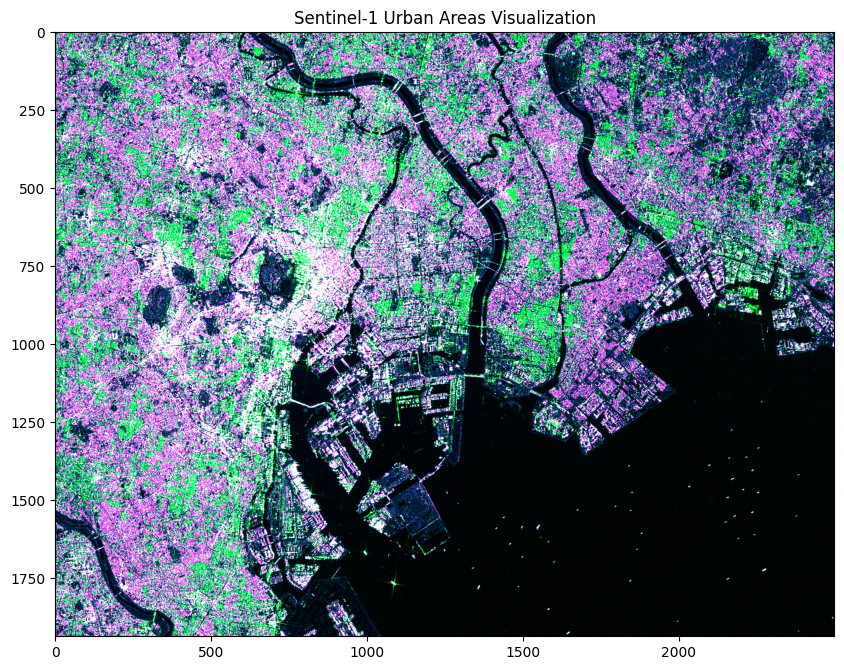

In [11]:
urban_color = s1_urban_areas_from_gamma0(img_vv, img_vh, unit='linear', return_mask=False)
urban_color_u8 = (urban_color * 255).round().astype(np.uint8)

# 可視化
plt.figure(figsize=(16, 8), dpi=100, facecolor='white', edgecolor='black')
plt.imshow(urban_color_u8)
plt.title('Sentinel-1 Urban Areas Visualization')
plt.savefig(os.path.join(PATH_OUTPUT, 'sentinel1_urban_areas.png'), bbox_inches='tight', pad_inches=0.1)
plt.show();
plt.imsave(os.path.join(PATH_OUTPUT, 'sentinel1_urban_areas_vv_vh.png'), urban_color_u8)

## 関数チェック

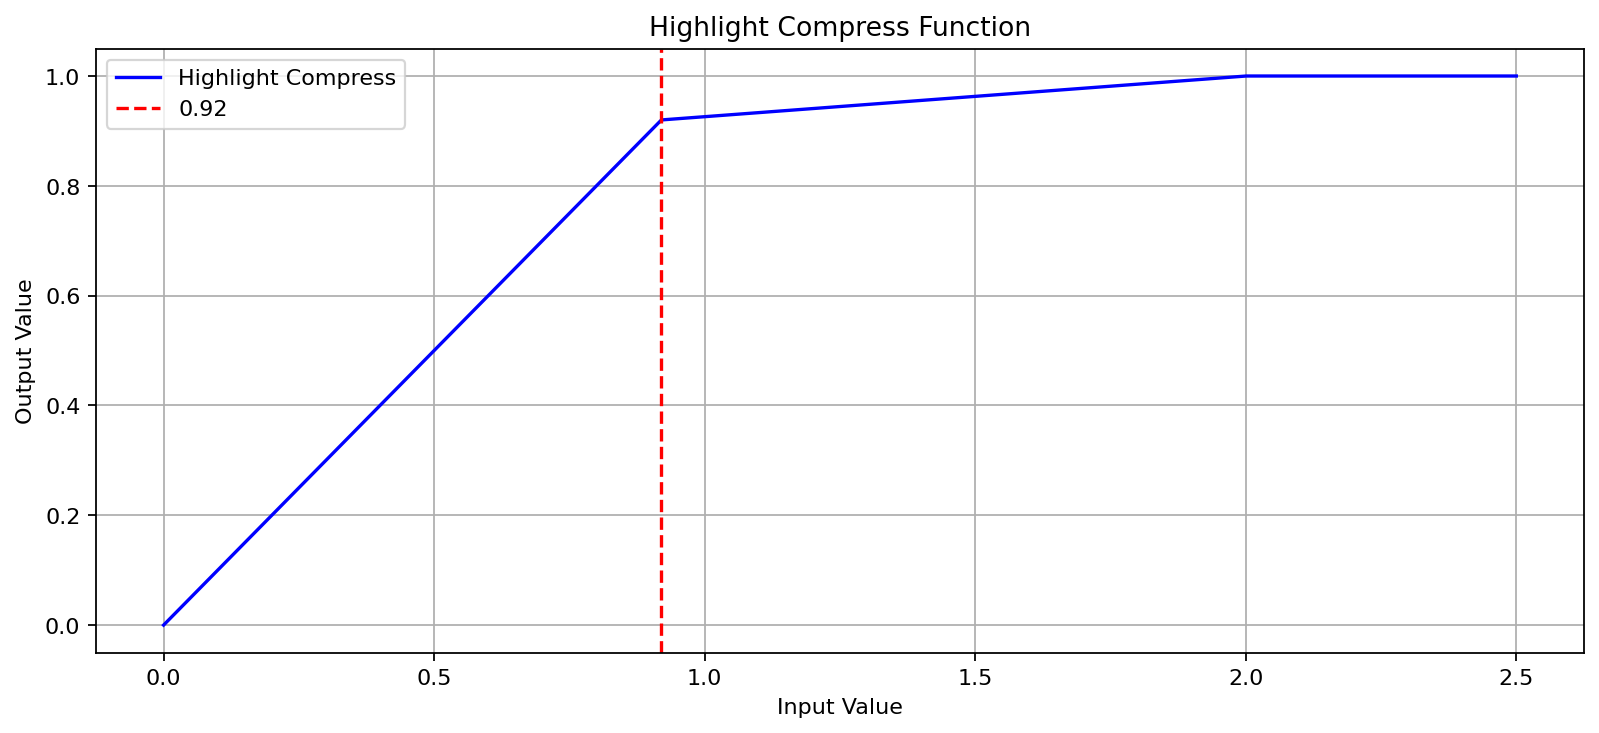

In [12]:
hc_data = highlight_compress(np.linspace(0, 2.5, 512), 0.0, 1)

# 可視化
plt.figure(figsize=(12, 5), dpi=160, facecolor='white', edgecolor='black')
plt.plot(np.linspace(0, 2.5,  512), hc_data, label='Highlight Compress', color='blue')
plt.title('Highlight Compress Function')
plt.xlabel('Input Value')
plt.ylabel('Output Value')
plt.grid(True)
plt.axvline(x=0.92, color='red', linestyle='--', label='0.92')
plt.legend()
plt.savefig(os.path.join(PATH_OUTPUT, 'highlight_compress_function.png'), bbox_inches='tight', pad_inches=0.1)
plt.show();